# Clustering

**Scenario:** supermarket_net_sales_forecast  
**Generated:** 2026-06-09  
**Key Parameters:**
- Forecast Horizon: 12 weeks
- Time Granularity: Weekly (Thursdays)
- Target Column: TOTAL_NET_SALES

This notebook clusters **regular** (smooth) time series using K-Means after profiling has been completed in Notebook 03.

Steps:
1. Load profiled data and filter to regular series
2. Winsorize and standardize data
3. **✅ CHECK POINT** — Set the number of clusters to try
4. Evaluate optimal clusters (Elbow + Silhouette)
5. **✅ CHECK POINT** — Choose final number of clusters
6. Assign cluster labels
7. **✅ CHECK POINT** — Visualize clusters and review
8. Save results

## Packages
Load the packages required for this notebook

In [1]:
# data elaboration functions
import pandas as pd
import numpy as np
from pathlib import Path
import os

# datetime functions
import datetime as dt

# plot functions
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# data science functions
from kneed import KneeLocator
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# statistical functions
from scipy.stats.mstats import winsorize

print("✅ Packages loaded successfully.")

✅ Packages loaded successfully.


## Setup & Configuration
Define configuration parameters for local execution

In [11]:
# Time series configuration
date_var = 'WEEK_START_DT'
date_format = '%Y-%m-%d'
id = 'product_name'
unique_id = 'STORE_LOCATION_ID'
frequency = 'W'
y = 'TOTAL_NET_SALES'

# Local data configuration
LOCAL_FOLDER = "supermarket_net_sales"
INPUT_TABLE = "df_final"
PROFILING_TABLE = "df_profiling"
OUTPUT_TABLE = "df_profiling_clustering"

# CUSTOMIZED: Set root_path for local demo execution
root_path = Path.cwd().parent

# Winsorizing parameters
highest = 0.05
lowest = 0.05

# CUSTOMIZED: Increased from 5 to 10 based on data scientist input (48 regular series)
try_clusters = 10

# Set seed for reproducibility
sample_seed_kmeans = 789

print("Configuration loaded:")
print(f"  - Date variable: {date_var}")
print(f"  - Target variable: {y}")
print(f"  - Unique ID: {unique_id}")
print(f"  - Max clusters to try: {try_clusters}")
print(f"  - Winsorizing: highest={highest}, lowest={lowest}")
print(f"  - Root path: {root_path}")
print(f"  - Data path: {root_path / 'data' / LOCAL_FOLDER}")

Configuration loaded:
  - Date variable: WEEK_START_DT
  - Target variable: TOTAL_NET_SALES
  - Unique ID: STORE_LOCATION_ID
  - Max clusters to try: 10
  - Winsorizing: highest=0.05, lowest=0.05
  - Root path: c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator-agent
  - Data path: c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator-agent\data\supermarket_net_sales


## Helper Functions
Utility functions for plotting

In [3]:
def find_date(df: pd.DataFrame) -> str:
    """
    Finds date columns in a dataframe
    """
    dates = list(df.select_dtypes(include=['datetime','datetime64[ns, UTC]', 'datetime64[ns]']).drop_duplicates().columns)
    if len(dates) == 1:
        date_col = dates[0]
    elif len(dates) == 0:
        dates = list(df.select_dtypes(include=['period[M]']).drop_duplicates().columns)
        date_col = dates[0] if dates else None
    else:
        date_col = dates[0]
    return str(date_col)


def sliding_line_plot(df: pd.DataFrame, id_col: str, serie_to_plot: str, i, chart_title: str = "") -> go.Figure:
    """
    Creates a time series plot with sliding dates
    """
    df = df.copy()
    date = find_date(df)
    df.sort_values(date, inplace=True)

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=list(df.loc[df[id_col] == i, date]),
        y=list(df.loc[df[id_col] == i, serie_to_plot]),
        name=str(i)
    ))

    if chart_title != "":
        fig.update_layout(title_text=chart_title)
    else:
        chart_title = serie_to_plot.capitalize() + ' ' + str(id_col) + ' ' + str(i)
        fig.update_layout(title_text=chart_title)

    fig.update_layout(
        xaxis=dict(
            rangeselector=dict(
                buttons=list([
                    dict(count=1, label="1m", step="month", stepmode="backward"),
                    dict(count=3, label="3m", step="month", stepmode="backward"),
                    dict(count=6, label="6m", step="month", stepmode="backward"),
                    dict(count=1, label="YTD", step="year", stepmode="todate"),
                    dict(count=1, label="1y", step="year", stepmode="backward"),
                    dict(step="all")
                ])
            ),
            rangeslider=dict(visible=True),
            type="date"
        )
    )
    return fig

print("✅ Helper functions loaded.")

✅ Helper functions loaded.


## Load Data
Load data from local parquet files (demo mode)

In [4]:
# Load prepared data
data_path = root_path / "data" / LOCAL_FOLDER
df_final = pd.read_parquet(data_path / f"{INPUT_TABLE}.parquet")
print(f"✅ Loaded df_final: {len(df_final)} rows, {len(df_final.columns)} columns")
print(f"   Date range: {df_final[date_var].min()} to {df_final[date_var].max()}")
print(f"   Unique stores: {df_final[unique_id].nunique()}")
df_final.head()

✅ Loaded df_final: 5150 rows, 95 columns
   Date range: 2023-04-03 00:00:00 to 2025-03-17 00:00:00
   Unique stores: 50


,STORE_LOCATION_ID,WEEK_START_DT,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,HOLIDAY_CHRISTMAS,HOLIDAY_BOXING_DAY,HOLIDAY_AFTER_THANKSGIVING,EVENT_VALENTINES,EVENT_MOTHERS_DAY,EVENT_FATHERS_DAY,EVENT_HALLOWEEN,EVENT_BLACK_FRIDAY,EVENT_CHINESE_NEW_YEAR,EVENT_STANLEY_CUP_FINAL
0,1,2023-04-03,522814.849132,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2023-04-10,620024.491881,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,2023-04-17,623209.751040,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,2023-04-24,641359.169727,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2023-05-01,615285.571504,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Load profiling results from notebook 03
df_profiling = pd.read_parquet(data_path / f"{PROFILING_TABLE}.parquet")
print(f"✅ Loaded df_profiling: {len(df_profiling)} rows")
print(f"\nProfile distribution:")
print(df_profiling['profile'].value_counts())

✅ Loaded df_profiling: 50 rows

Profile distribution:
profile
regular    48
erratic     2
Name: count, dtype: int64


## Filter Regular Time Series
Clustering is applied only to series classified as **regular** (smooth) by the profiling step.

In [6]:
list_id_profiling = list(df_profiling.loc[df_profiling['profile']=='regular', unique_id].unique())
print(f"Number of regular time series: {len(list_id_profiling)}")

mask = df_final[unique_id].isin(list_id_profiling)
df = df_final.loc[mask == True, ].copy()
print(f"Filtered dataframe rows: {len(df)}")
df.head()

Number of regular time series: 48
Filtered dataframe rows: 4944


,STORE_LOCATION_ID,WEEK_START_DT,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,HOLIDAY_CHRISTMAS,HOLIDAY_BOXING_DAY,HOLIDAY_AFTER_THANKSGIVING,EVENT_VALENTINES,EVENT_MOTHERS_DAY,EVENT_FATHERS_DAY,EVENT_HALLOWEEN,EVENT_BLACK_FRIDAY,EVENT_CHINESE_NEW_YEAR,EVENT_STANLEY_CUP_FINAL
0,1,2023-04-03,522814.849132,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2023-04-10,620024.491881,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,2023-04-17,623209.751040,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,2023-04-24,641359.169727,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2023-05-01,615285.571504,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


## Winsorizing data
Cap extreme values at top and bottom 5% to reduce the impact of outliers on clustering.

In [7]:
df_win_sum = df.groupby([unique_id, date_var])[y].apply(
    lambda x: np.sum(winsorize(x, (highest, lowest)))).reset_index()
df_win_sum.columns = [unique_id, date_var, "sum_" + y]
print(f"Winsorized data shape: {df_win_sum.shape}")
df_win_sum.head()

Winsorized data shape: (4944, 3)


,STORE_LOCATION_ID,WEEK_START_DT,sum_TOTAL_NET_SALES
0,1,2023-04-03,522814.849132
1,1,2023-04-10,620024.491881
2,1,2023-04-17,623209.751040
3,1,2023-04-24,641359.169727
4,1,2023-05-01,615285.571504


## Standardizing data
Check for zero values after winsorizing and standardize the target variable.

In [8]:
scaler = StandardScaler()

if len(set(list_id_profiling) - set(list(df_win_sum[unique_id].unique()))) > 0:
    list_id_profiling = list(set(list_id_profiling) - set(list(df_win_sum[unique_id].unique())))
    print(unique_id, list_id_profiling, "has/have 0", y, "after winsorizing")
    mask = (df_win_sum[y]!=np.nan) & (~df_win_sum[unique_id].isin(list_id_profiling))
    
    print("Standardizing data for ids without NA values after winsorizing")
    df_win_sum['y_std'] = scaler.fit_transform(df_win_sum[[y]])
    df_std = df_win_sum.loc[mask, ].pivot(index=date_var, columns=id, values='y_std').reset_index()
    charvec = df_std[date_var].dt.strftime('%Y-%m-%d')
    df_std.set_index(date_var, inplace=True)
else:
    mask = (df[y]!=np.nan)
    
    print("Standardizing data for ids without NA values after winsorizing")
    df['y_std'] = scaler.fit_transform(df[[y]])
    df_std = df.loc[mask, ].pivot(index=date_var, columns=unique_id, values='y_std').reset_index()
    charvec = df_std[date_var].dt.strftime('%Y-%m-%d')
    df_std.set_index(date_var, inplace=True)
    print("NO", id, "has/have 0", y, "after winsorizing")

print(f"\nStandardized matrix shape: {df_std.shape}")
df_std.head()

Standardizing data for ids without NA values after winsorizing
NO product_name has/have 0 TOTAL_NET_SALES after winsorizing

Standardized matrix shape: (103, 48)


STORE_LOCATION_ID,1,2,3,4,5,6,7,8,9,10,...,40,41,42,43,44,46,47,48,49,50
WEEK_START_DT,,,,,,,,,,,,,,,,,,,,,
2023-04-03,-0.056520,0.141403,0.127926,-0.325414,0.384767,-0.304012,-0.272348,-0.264505,-1.558170,-1.140310,...,-0.998179,0.915702,-1.210442,-0.638282,-1.242714,-0.891935,-1.102921,-0.366032,0.544935,-1.594804
2023-04-10,0.426934,0.746811,1.072186,0.144596,0.807125,0.433002,-0.043220,0.188998,-1.253726,-0.581207,...,-0.711257,1.670241,-0.765604,-0.110998,-0.927816,-0.529496,-0.999416,0.177004,1.252636,-1.516276
2023-04-17,0.442776,0.851163,0.765662,0.167325,0.802797,0.288663,-0.290334,0.201778,-1.209703,-0.639143,...,-0.723515,1.495156,-0.826318,-0.434281,-0.943241,-0.346558,-1.011776,-0.053507,1.051255,-1.603325
2023-04-24,0.533038,0.686913,0.699185,-0.005133,0.697289,0.380826,-0.280094,0.076341,-1.173763,-0.763638,...,-0.893560,1.263201,-1.115516,-0.367551,-1.028694,-0.575848,-1.237002,-0.193282,1.052023,-1.534216
2023-05-01,0.403366,0.677880,0.719653,0.068527,0.949301,0.351350,-0.186076,0.198152,-0.972201,-0.845227,...,-0.819231,1.380183,-1.069683,-0.357826,-1.109778,-0.642868,-1.443500,-0.087279,1.192614,-1.344516


## Defining a set of IDs to cluster with NO NaN
K-Means requires a complete matrix. Drop any series with missing values.

In [9]:
df_std_no_nan = df_std.dropna()
print('Number of time periods with complete data:', len(df_std_no_nan))

if len(df_std_no_nan) == 0:
    list_id_cluster = []
    df_cluster = df_std.loc[:, list_id_cluster].dropna().T
else:
    list_id_cluster = list(set(list(df_std.columns)) - set([date_var]))
    df_cluster = df_std.loc[:, list_id_cluster].dropna().T

print(f'IDs available for clustering: {len(list_id_cluster)}')
print(f'Clustering matrix shape (IDs x time_periods): {df_cluster.shape}')
df_cluster.head()

Number of time periods with complete data: 103
IDs available for clustering: 48
Clustering matrix shape (IDs x time_periods): (48, 103)


WEEK_START_DT,2023-04-03,2023-04-10,2023-04-17,2023-04-24,2023-05-01,2023-05-08,2023-05-15,2023-05-22,2023-05-29,2023-06-05,...,2025-01-13,2025-01-20,2025-01-27,2025-02-03,2025-02-10,2025-02-17,2025-02-24,2025-03-03,2025-03-10,2025-03-17
STORE_LOCATION_ID,,,,,,,,,,,,,,,,,,,,,
1,-0.056520,0.426934,0.442776,0.533038,0.403366,0.673879,0.743337,0.618316,0.593224,0.511261,...,0.196838,0.357416,0.243311,0.431231,0.322107,0.297091,0.433021,0.100195,0.210294,0.435654
2,0.141403,0.746811,0.851163,0.686913,0.677880,1.022465,0.621299,0.720877,0.860045,1.016653,...,0.511752,0.744851,0.592222,0.785467,0.678177,0.729661,0.952187,0.519894,0.533968,0.885326
3,0.127926,1.072186,0.765662,0.699185,0.719653,0.989313,0.739116,0.725494,0.682535,0.587168,...,0.386085,0.687687,0.734296,0.695547,0.532173,0.635469,0.618664,0.518953,0.502498,0.688892
4,-0.325414,0.144596,0.167325,-0.005133,0.068527,0.239519,0.175437,0.134784,0.188902,0.113979,...,-0.057971,-0.011432,-0.027101,0.019295,0.026779,0.060710,0.004658,-0.243337,0.069449,0.269086
5,0.384767,0.807125,0.802797,0.697289,0.949301,1.325388,1.013158,0.998348,1.068245,0.983532,...,0.489463,0.772916,0.759630,0.747452,0.482753,0.497698,0.807901,0.652298,0.547595,0.844469


## ✅ CHECK POINT with the data scientist: set the number of clusters to try

Before running the elbow and silhouette analysis, please confirm or adjust `try_clusters` — the maximum number of clusters to evaluate.

**Current value:** `try_clusters = 5`  
**Recommendation:** For 30-50 regular series, trying 5-10 clusters is typically sufficient.

In [10]:
# Setting up date range
start_date = min(df_cluster.index) if len(df_cluster) > 0 else None
print('Start date:', start_date)
end_date = max(df_cluster.index) if len(df_cluster) > 0 else None
print('End date:', end_date)

# Define the number of clusters
print(f"\n📊 Clustering {len(list_id_cluster)} regular series")
print(f"🔢 Try clusters: {try_clusters}")
print(f"\n⏸️  CHECKPOINT: Review try_clusters value before proceeding to elbow/silhouette analysis.")

# K-means setup
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
}

Start date: 1
End date: 50

📊 Clustering 48 regular series
🔢 Try clusters: 5

⏸️  CHECKPOINT: Review try_clusters value before proceeding to elbow/silhouette analysis.


## Choosing the Appropriate Number of Clusters
Two methods are used to evaluate the appropriate number of clusters:
- **The Elbow method** — looks for the "knee" in SSE
- **The Silhouette coefficient** — measures cluster cohesion and separation

### The Elbow Method

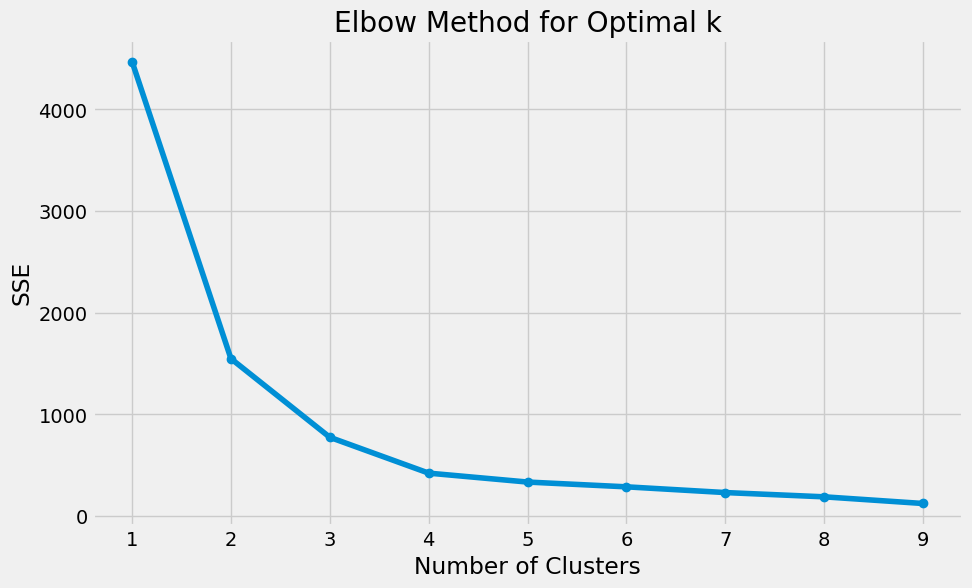

In [12]:
X = np.array(df_cluster)

# A list holds the SSE values for each k
sse = []
for k in range(1, try_clusters):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit_predict(X)
    sse.append(kmeans.inertia_)

plt.style.use("fivethirtyeight")
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, try_clusters), sse, marker='o')
ax.set_xticks(range(1, try_clusters))
ax.set_xlabel("Number of Clusters")
ax.set_ylabel("SSE")
ax.set_title("Elbow Method for Optimal k")

chart_path = os.path.join(root_path, "data", LOCAL_FOLDER, "charts", f"elbow_method_try_clusters_{try_clusters}.png")
os.makedirs(os.path.dirname(chart_path), exist_ok=True)
fig.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()

In [13]:
kl = KneeLocator(range(1, try_clusters), sse, curve="convex", direction="decreasing")
print(f"📐 Elbow method: optimal number of clusters = {kl.elbow}")

📐 Elbow method: optimal number of clusters = 3


### The Silhouette Coefficient
The silhouette coefficient measures cluster cohesion and separation. Values range from -1 to 1; larger values indicate better clustering.

Silhouette coefficients:
   Silhouette Score
2          0.579833
3          0.541865
4          0.532405
5          0.506409
6          0.425384
7          0.389667
8          0.346560
9          0.412628


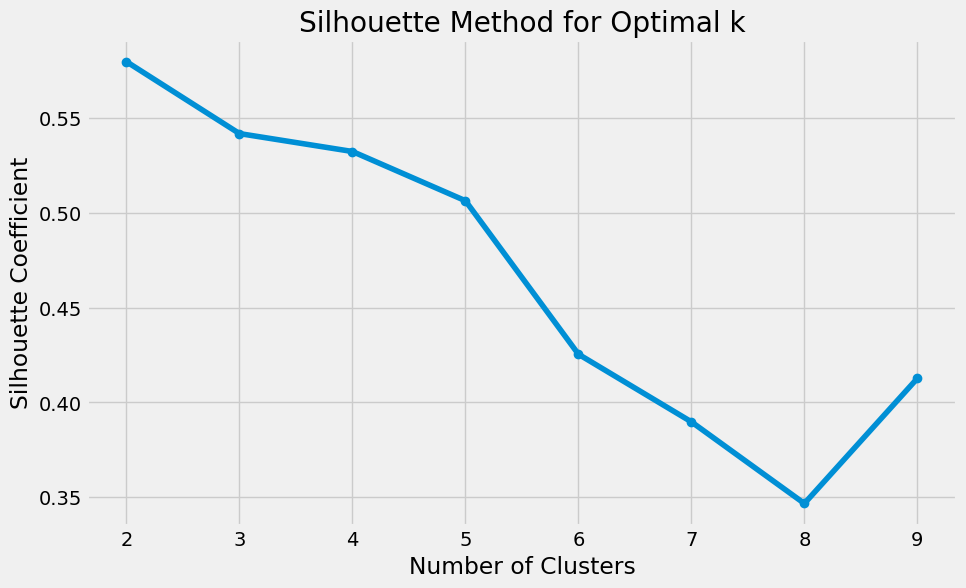


📐 Silhouette method: optimal number of clusters = 2


In [14]:
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, try_clusters):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_coefficients.append(score)

print("Silhouette coefficients:")
print(pd.DataFrame(silhouette_coefficients, index=range(2, try_clusters), columns=['Silhouette Score']))

plt.style.use("fivethirtyeight")
plt.figure(figsize=(10, 6))
plt.plot(range(2, try_clusters), silhouette_coefficients, marker='o')
plt.xticks(range(2, try_clusters))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.title("Silhouette Method for Optimal k")

chart_path = os.path.join(root_path, "data", LOCAL_FOLDER, "charts", f"silhouette_method_try_clusters_{try_clusters}.png")
os.makedirs(os.path.dirname(chart_path), exist_ok=True)
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()

df_sil_coeff = pd.DataFrame(silhouette_coefficients).reset_index()
optimal_silhouette_coefficients = df_sil_coeff.loc[df_sil_coeff[0] == max(silhouette_coefficients), 'index'].values[0] + 2
print(f"\n📐 Silhouette method: optimal number of clusters = {optimal_silhouette_coefficients}")

## ✅ CHECK POINT with the data scientist: choose the number of clusters

Based on the Elbow and Silhouette analysis above, choose the final number of clusters.

The agent will use the maximum of the two methods unless you specify otherwise.

In [16]:
# CUSTOMIZED: Data scientist chose 4 clusters (silhouette 0.53, elbow suggested 3)
chosen_clusters = 4
print(f"\n🎯 Chosen number of clusters: {chosen_clusters}")
print(f"   (Elbow=3, Silhouette=2, Data scientist choice=4)")
print(f"\n⏸️  CHECKPOINT: Confirmed chosen_clusters = {chosen_clusters}")


🎯 Chosen number of clusters: 4
   (Elbow=3, Silhouette=2, Data scientist choice=4)

⏸️  CHECKPOINT: Confirmed chosen_clusters = 4


## K-Means Clustering
Assign cluster labels to each regular time series.

In [17]:
kmeans = KMeans(n_clusters=chosen_clusters, **kmeans_kwargs)
identified_clusters = kmeans.fit_predict(X)

df_cluster.loc[:, 'cluster'] = identified_clusters
print(f"✅ Clustering complete. Shape: {df_cluster.shape}")
print(f"\nCluster distribution:")
for cluster in range(chosen_clusters):
    num_in_cluster = len(df_cluster.loc[df_cluster['cluster'] == cluster])
    print(f"   Cluster {cluster}: {num_in_cluster} series")
df_cluster.head()

✅ Clustering complete. Shape: (48, 104)

Cluster distribution:
   Cluster 0: 19 series
   Cluster 1: 11 series
   Cluster 2: 15 series
   Cluster 3: 3 series


WEEK_START_DT,2023-04-03 00:00:00,2023-04-10 00:00:00,2023-04-17 00:00:00,2023-04-24 00:00:00,2023-05-01 00:00:00,2023-05-08 00:00:00,2023-05-15 00:00:00,2023-05-22 00:00:00,2023-05-29 00:00:00,2023-06-05 00:00:00,...,2025-01-20 00:00:00,2025-01-27 00:00:00,2025-02-03 00:00:00,2025-02-10 00:00:00,2025-02-17 00:00:00,2025-02-24 00:00:00,2025-03-03 00:00:00,2025-03-10 00:00:00,2025-03-17 00:00:00,cluster
STORE_LOCATION_ID,,,,,,,,,,,,,,,,,,,,,
1,-0.056520,0.426934,0.442776,0.533038,0.403366,0.673879,0.743337,0.618316,0.593224,0.511261,...,0.357416,0.243311,0.431231,0.322107,0.297091,0.433021,0.100195,0.210294,0.435654,1
2,0.141403,0.746811,0.851163,0.686913,0.677880,1.022465,0.621299,0.720877,0.860045,1.016653,...,0.744851,0.592222,0.785467,0.678177,0.729661,0.952187,0.519894,0.533968,0.885326,1
3,0.127926,1.072186,0.765662,0.699185,0.719653,0.989313,0.739116,0.725494,0.682535,0.587168,...,0.687687,0.734296,0.695547,0.532173,0.635469,0.618664,0.518953,0.502498,0.688892,1
4,-0.325414,0.144596,0.167325,-0.005133,0.068527,0.239519,0.175437,0.134784,0.188902,0.113979,...,-0.011432,-0.027101,0.019295,0.026779,0.060710,0.004658,-0.243337,0.069449,0.269086,2
5,0.384767,0.807125,0.802797,0.697289,0.949301,1.325388,1.013158,0.998348,1.068245,0.983532,...,0.772916,0.759630,0.747452,0.482753,0.497698,0.807901,0.652298,0.547595,0.844469,1


## Plotting Clustered Regular Series

In [18]:
# Reshape data for plotting
df_to_plot = pd.melt(df_cluster.reset_index(), id_vars=[unique_id, 'cluster'], var_name=date_var, value_name='y_std')
df_to_plot[date_var] = pd.to_datetime(df_to_plot[date_var])
df_to_plot = pd.merge(df_to_plot, right=df[[unique_id, date_var, y]].drop_duplicates(), on=[unique_id, date_var], how='left', validate='1:1')
print(f"Data for plotting prepared: {len(df_to_plot)} rows")
print(f"Unique series with cluster labels: {df_to_plot[[unique_id, 'cluster']].drop_duplicates().groupby('cluster').count()}")

Data for plotting prepared: 4944 rows
Unique series with cluster labels:          STORE_LOCATION_ID
cluster                   
0                       19
1                       11
2                       15
3                        3


### ✅ CHECK POINT with the data scientist: plot max 10 time series per cluster

Plot up to 10 time series per cluster chosen randomly. Review the cluster assignments:
- Do the clusters make visual sense?
- Any hints on consumption drivers (weather, promotions)?


=== Cluster 0 ===


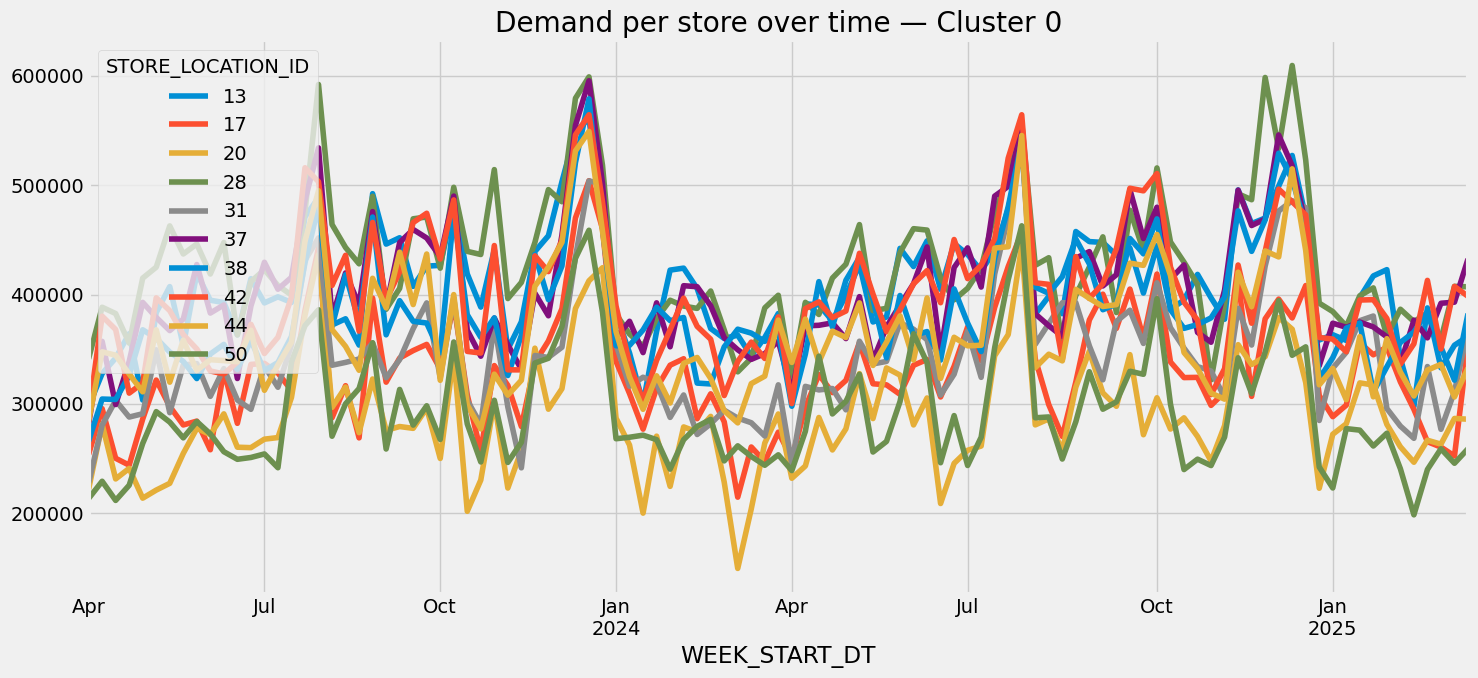


=== Cluster 1 ===


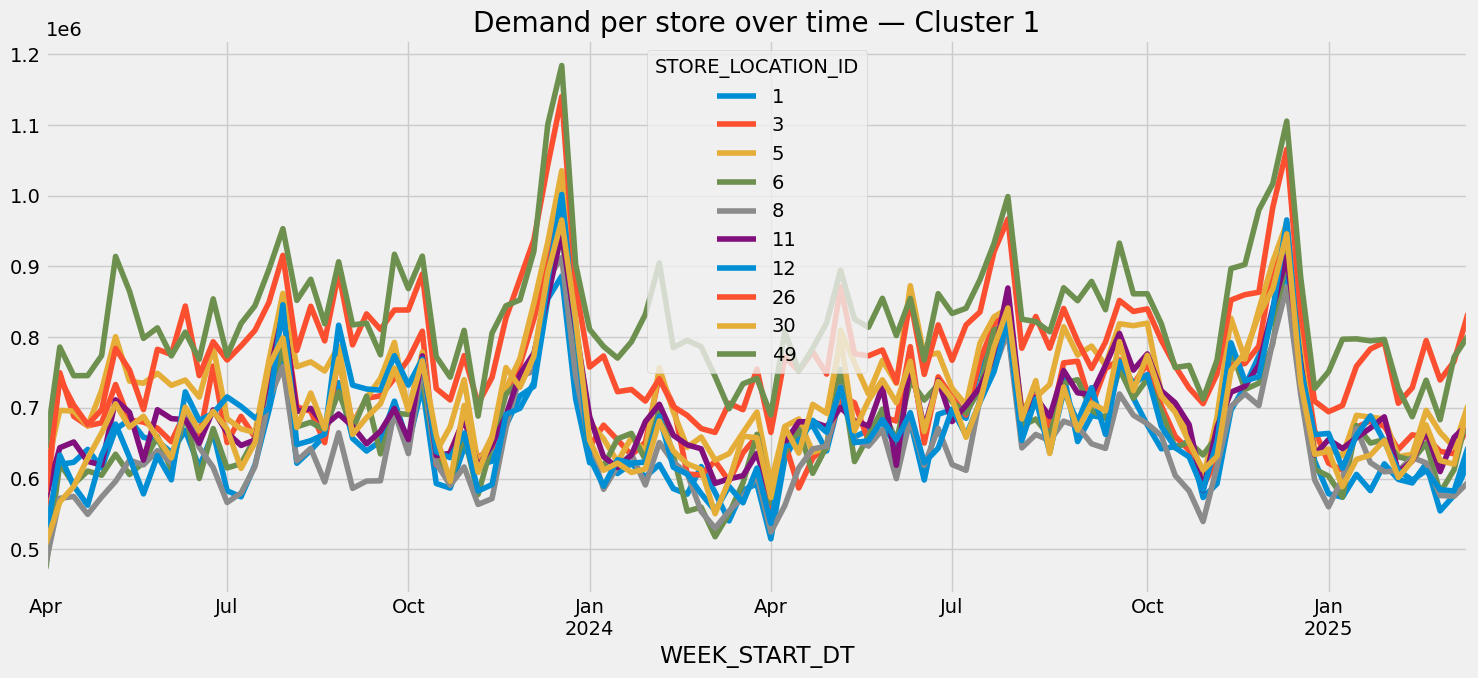


=== Cluster 2 ===


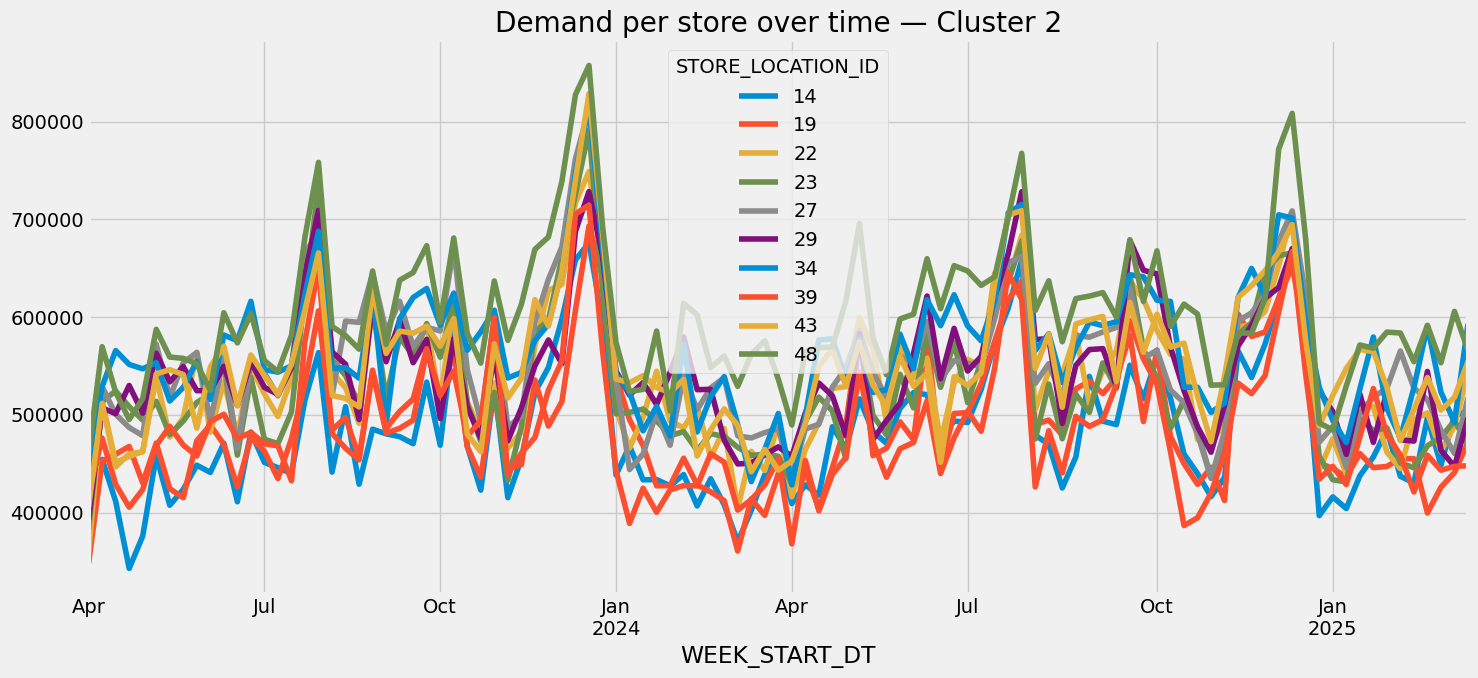


=== Cluster 3 ===


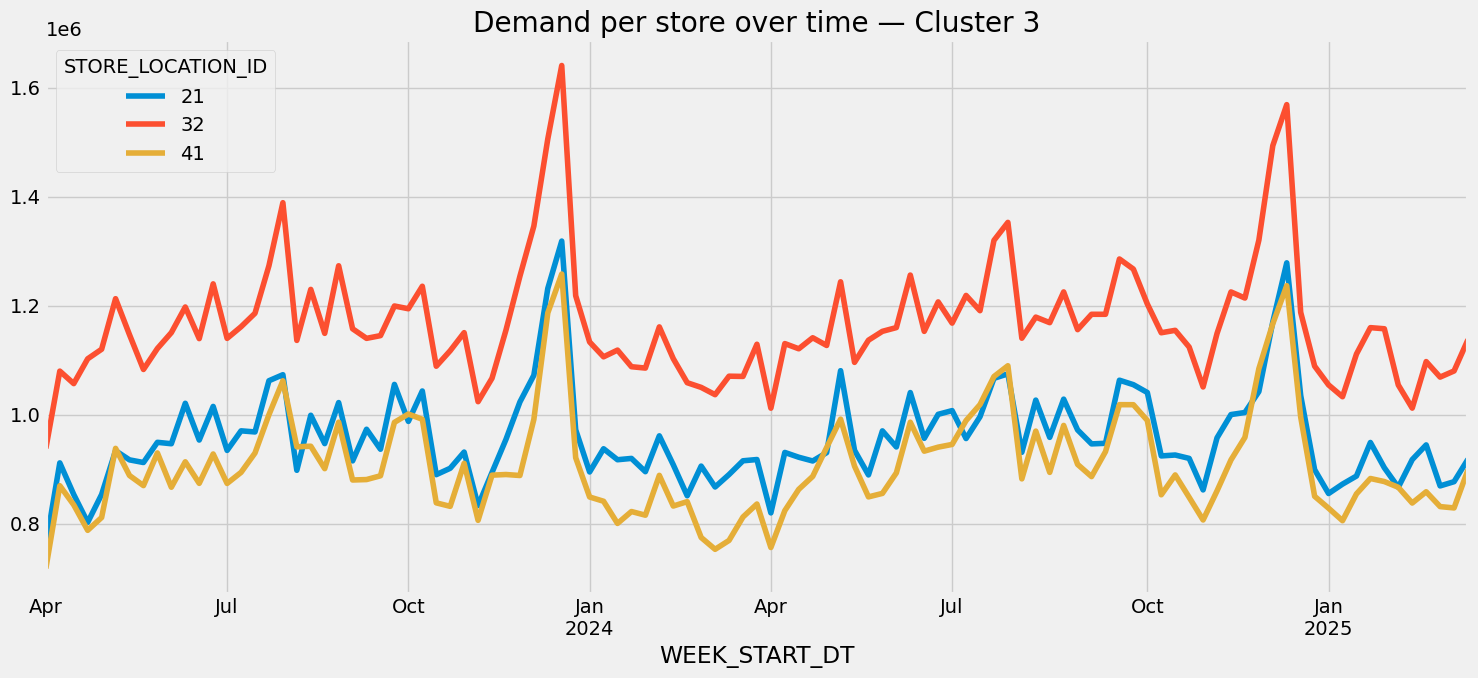


✅ Total plots created: 33


In [19]:
import random
random.seed(sample_seed_kmeans)

cluster_plots = {}

for cluster in sorted(list(df_to_plot['cluster'].unique())):
    print(f'\n=== Cluster {cluster} ===')
    list_ids_in_cluster = list(df_to_plot.loc[df_to_plot['cluster'] == cluster, unique_id].unique())
    plot_ids = list_ids_in_cluster if len(list_ids_in_cluster) <= 10 else random.sample(list_ids_in_cluster, 10)

    # Overview plot for cluster
    plot_df = (
        df_to_plot.loc[df_to_plot[unique_id].isin(plot_ids), :]
        .groupby([unique_id, date_var])[y]
        .mean()
        .reset_index()
        .pivot(index=date_var, columns=unique_id, values=y)
    )
    ax = plot_df.plot(figsize=(15, 7))
    ax.set_title(f"Demand per store over time — Cluster {cluster}")
    fig = ax.get_figure()
    fig.tight_layout()

    chart_name = f"demand_per_store_cluster_{cluster}"
    chart_path = os.path.join(root_path, "data", LOCAL_FOLDER, "charts", chart_name + ".png")
    os.makedirs(os.path.dirname(chart_path), exist_ok=True)
    fig.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # Individual interactive plots
    for i in plot_ids:
        chart_title = f"{unique_id} {i} — Regular cluster {cluster}"
        plot = sliding_line_plot(df_to_plot, unique_id, y, i, chart_title=chart_title)
        save_path = os.path.join(root_path, "data", LOCAL_FOLDER, "charts", f"{unique_id}_{i}_cluster_{cluster}.html")
        plot.write_html(save_path)
        cluster_plots[f"{unique_id}_{i}_cluster_{cluster}"] = plot

print(f"\n✅ Total plots created: {len(cluster_plots)}")

In [20]:
# Display one sample interactive plot per cluster
for cluster in sorted(list(df_to_plot['cluster'].unique())):
    keys_for_cluster = [k for k in cluster_plots.keys() if k.endswith(f"_cluster_{cluster}")]
    if keys_for_cluster:
        print(f"\nSample plot for Cluster {cluster}:")
        cluster_plots[keys_for_cluster[0]].show()


Sample plot for Cluster 0:



Sample plot for Cluster 1:



Sample plot for Cluster 2:



Sample plot for Cluster 3:


## Saving Results
Merge cluster labels with profiling results and save locally.

In [21]:
df_profiling_clustering = pd.merge(
    df_profiling,
    df_cluster[['cluster']].reset_index().rename(columns={'index': unique_id}),
    on=unique_id,
    how='left',
    validate='1:1'
)
print(f"Merged profiling with clusters: {len(df_profiling_clustering)} rows")
print("\nProfile vs Cluster distribution:")
print(pd.pivot_table(df_profiling_clustering, index='profile', columns='cluster', values=unique_id, aggfunc='count', fill_value=0))

# Create combined profile_cluster column
df_profiling_clustering['profile_cluster'] = df_profiling_clustering['profile']
df_profiling_clustering.loc[df_profiling_clustering['profile'] == 'regular', 'profile_cluster'] = df_profiling_clustering['cluster']
df_profiling_clustering.drop(columns=['profile', 'cluster'], inplace=True)
df_profiling_clustering['profile_cluster'] = df_profiling_clustering['profile_cluster'].astype(str)

print("\nFinal profile_cluster distribution:")
print(df_profiling_clustering['profile_cluster'].value_counts())
df_profiling_clustering.head()

Merged profiling with clusters: 50 rows

Profile vs Cluster distribution:
cluster  0.0  1.0  2.0  3.0
profile                    
regular   19   11   15    3

Final profile_cluster distribution:
profile_cluster
0.0        19
2.0        15
1.0        11
3.0         3
erratic     2
Name: count, dtype: int64


,STORE_LOCATION_ID,type,k,low_demand,cv2,adi,sddi,profile_cluster
0,1,perc_quant_999,103,8940.914706,0.008781,2902.041137,55729.031602,1.0
1,2,perc_quant_999,103,10579.725185,0.007291,4899.035184,60100.748047,1.0
2,3,perc_quant_999,103,9874.136855,0.008653,2205.769570,65536.257704,1.0
3,4,perc_quant_999,103,8020.743506,0.009046,2260.903782,52457.242364,2.0
4,5,perc_quant_999,103,10278.655113,0.009100,1648.101756,65918.562441,1.0


In [22]:
# Save results locally
output_path = root_path / "data" / LOCAL_FOLDER / f"{OUTPUT_TABLE}.parquet"
df_profiling_clustering.to_parquet(output_path, index=False)
print(f"✅ Results saved to: {output_path}")
print(f"   Total series: {len(df_profiling_clustering)}")
print(f"   Profile clusters: {df_profiling_clustering['profile_cluster'].unique().tolist()}")

✅ Results saved to: c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator-agent\data\supermarket_net_sales\df_profiling_clustering.parquet
   Total series: 50
   Profile clusters: ['1.0', '2.0', '0.0', '3.0', 'erratic']
